# Control Results Summary

This notebook loads `results/controls_db.xlsx` and prints compact temporal-control tables for the biggest-backbone models.

For each dataset, model, and probe, the table first selects the best **main-task** layer by test primary metric. Shuffle and single-frame values are then read at that exact same layer. No max is taken over control layers.

- MVP primary metric: pair consistency
- IntPhys2 primary metric: VOE accuracy


In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "results" / "controls_db.xlsx").exists():
            return candidate
    raise FileNotFoundError("Could not find results/controls_db.xlsx from the current directory.")


REPO_ROOT = find_repo_root()
CONTROLS_XLSX = REPO_ROOT / "results" / "controls_db.xlsx"
MAIN_XLSX = REPO_ROOT / "results" / "visualization_ready_results.xlsx"

controls = pd.read_excel(CONTROLS_XLSX, sheet_name="controls_db")
main_workbook = pd.ExcelFile(MAIN_XLSX)

print(f"controls: {CONTROLS_XLSX}")
print(f"main-task reference: {MAIN_XLSX}")


controls: /gpfs/home2/spunzo1/Probe4Physics/results/controls_db.xlsx
main-task reference: /gpfs/home2/spunzo1/Probe4Physics/results/visualization_ready_results.xlsx


In [31]:
MODEL_SPECS = [
    {
        "row": "V-JEPA",
        "control_backbone": "jepa_v1",
        "main_model": "V-JEPA",
        "main_backbone": "ViT-H/16",
        "relative_layers": {"Layer 0.25": 8, "Layer 0.5": 16, "Layer 0.75": 24, "Final layer": 32},
    },
    {
        "row": "V-JEPA 2",
        "control_backbone": "jepa_v2",
        "main_model": "V-JEPA 2",
        "main_backbone": "ViT-G/16",
        "relative_layers": {"Layer 0.25": 10, "Layer 0.5": 20, "Layer 0.75": 30, "Final layer": 40},
    },
    {
        "row": "V-JEPA 2.1",
        "control_backbone": "jepa_v2_1",
        "main_model": "V-JEPA 2.1",
        "main_backbone": "ViT-Gigantic/16",
        "relative_layers": {"Layer 0.25": 12, "Layer 0.5": 24, "Layer 0.75": 38, "Final layer": 48},
    },
    {
        "row": "VideoMAE",
        "control_backbone": "videomae",
        "main_model": "VideoMAE",
        "main_backbone": "ViT-H/16",
        "relative_layers": {"Layer 0.25": 8, "Layer 0.5": 16, "Layer 0.75": 24, "Final layer": 32},
    },
    {
        "row": "VideoMAE-v2",
        "control_backbone": "videomae_v2",
        "main_model": "VideoMAE-v2",
        "main_backbone": "ViT-G/16",
        "relative_layers": {"Layer 0.25": 10, "Layer 0.5": 20, "Layer 0.75": 30, "Final layer": 40},
    },
    {
        "row": "LTX-Video",
        "control_backbone": "ltx_video",
        "main_model": None,
        "main_backbone": "LTX-13B",
        "relative_layers": {},
    },
]

DATASETS = {
    "MVP": {
        "control_dataset": "mvp",
        "main_sheet": "main_mvp",
        "ltx_sheet": "ltx_mvp",
        "control_metric": "original_pair_consistency",
    },
    "IntPhys2": {
        "control_dataset": "intphys2",
        "main_sheet": "main_intphys",
        "ltx_sheet": "ltx_intphys",
        "control_metric": "original_voe_accuracy",
    },
}

PROBES = [("Linear", "linear"), ("MLP", "mlp"), ("Attentive", "temporal_attn")]


def _numeric_or_nan(value):
    return pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]


def _normalize_layer_value(value):
    if pd.isna(value):
        return ""
    numeric = _numeric_or_nan(value)
    if pd.notna(numeric):
        return str(int(numeric)) if float(numeric).is_integer() else str(float(numeric))
    return str(value).strip()


def _main_subset(model_spec, dataset_name, probe_label):
    cfg = DATASETS[dataset_name]
    if model_spec["row"] == "LTX-Video":
        df = main_workbook.parse(cfg["ltx_sheet"])
        return df[
            (df["Backbone"].astype(str) == model_spec["main_backbone"])
            & (df["Probe"].astype(str) == probe_label)
        ].copy()

    df = main_workbook.parse(cfg["main_sheet"])
    return df[
        (df["Model"].astype(str) == model_spec["main_model"])
        & (df["Backbone"].astype(str) == model_spec["main_backbone"])
        & (df["Probe"].astype(str) == probe_label)
    ].copy()


def best_main_row(model_spec, dataset_name, probe_label):
    subset = _main_subset(model_spec, dataset_name, probe_label)
    if subset.empty:
        return {"main": np.nan, "layer": "", "layer_label": "", "main_layer_raw": ""}

    subset["_metric"] = pd.to_numeric(subset["Test Primary Metric"], errors="coerce")
    subset = subset.dropna(subset=["_metric"])
    if subset.empty:
        return {"main": np.nan, "layer": "", "layer_label": "", "main_layer_raw": ""}

    row = subset.sort_values("_metric", ascending=False, kind="stable").iloc[0]
    raw_layer = row.get("Layer", "")
    raw_label = row.get("Layer Label", "") if "Layer Label" in row.index else ""

    layer = model_spec["relative_layers"].get(str(raw_layer).strip())
    if layer is None:
        numeric = _numeric_or_nan(raw_layer)
        layer = int(numeric) if pd.notna(numeric) and float(numeric).is_integer() else None

    layer_label = _normalize_layer_value(raw_label) if str(raw_label).strip() and not pd.isna(raw_label) else _normalize_layer_value(raw_layer)
    return {
        "main": float(row["_metric"]),
        "layer": "" if layer is None else int(layer),
        "layer_label": layer_label,
        "main_layer_raw": _normalize_layer_value(raw_layer),
    }


def _control_layer_labels(model_spec, dataset_name, probe_slug, layer):
    if layer == "":
        return set()
    cfg = DATASETS[dataset_name]
    subset = controls[
        (controls["dataset"].astype(str) == cfg["control_dataset"])
        & (controls["backbone"].astype(str) == model_spec["control_backbone"])
        & (controls["probe"].astype(str) == probe_slug)
    ].copy()
    layer_match = pd.to_numeric(subset["layer"], errors="coerce") == int(layer)
    labels = subset.loc[layer_match, "layer_label"].map(_normalize_layer_value).dropna()
    return {label for label in labels if label}


def control_value(model_spec, dataset_name, probe_slug, control_name, selected):
    cfg = DATASETS[dataset_name]
    subset = controls[
        (controls["dataset"].astype(str) == cfg["control_dataset"])
        & (controls["control"].astype(str) == control_name)
        & (controls["backbone"].astype(str) == model_spec["control_backbone"])
        & (controls["probe"].astype(str) == probe_slug)
    ].copy()
    if subset.empty:
        return np.nan

    layer = selected["layer"]
    layer_label = selected["layer_label"]
    main_layer_raw = selected["main_layer_raw"]

    layer_match = pd.Series(False, index=subset.index)
    if layer != "":
        layer_match = pd.to_numeric(subset["layer"], errors="coerce") == int(layer)

    label_values = subset["layer_label"].map(_normalize_layer_value) if "layer_label" in subset.columns else pd.Series("", index=subset.index)
    label_candidates = {str(layer_label).strip(), str(main_layer_raw).strip()}
    label_candidates.update(_control_layer_labels(model_spec, dataset_name, probe_slug, layer))
    label_candidates.discard("")
    label_match = label_values.isin(label_candidates) if label_candidates else pd.Series(False, index=subset.index)

    matched = subset[layer_match | label_match]
    if matched.empty:
        return np.nan

    values = pd.to_numeric(matched[cfg["control_metric"]], errors="coerce").dropna()
    if values.empty:
        return np.nan
    if len(values) > 1:
        values = values.drop_duplicates()
    return float(values.iloc[0])


def make_absolute_table():
    rows = {}
    selected_rows = []
    for model_spec in MODEL_SPECS:
        row = {}
        for dataset_name in DATASETS:
            for probe_label, probe_slug in PROBES:
                selected = best_main_row(model_spec, dataset_name, probe_label)
                row[(dataset_name, probe_label, "Main")] = selected["main"]
                row[(dataset_name, probe_label, "Shuffle")] = control_value(model_spec, dataset_name, probe_slug, "frame_shuffling", selected)
                row[(dataset_name, probe_label, "Single frame")] = control_value(model_spec, dataset_name, probe_slug, "single_frame", selected)
                selected_rows.append(
                    {
                        "Dataset": dataset_name,
                        "Model": model_spec["row"],
                        "Probe": probe_label,
                        "Main score": selected["main"],
                        "Selected layer": selected["layer"],
                        "Selected label": selected["layer_label"],
                        "Main layer raw": selected["main_layer_raw"],
                    }
                )
        rows[model_spec["row"]] = row
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "Model"
    table.columns = pd.MultiIndex.from_tuples(table.columns, names=["Dataset", "Probe", "Metric"])
    selected_layers = pd.DataFrame(selected_rows)
    return table, selected_layers


absolute_table, selected_layers = make_absolute_table()
absolute_table.round(2)


Dataset        MVP                                                                                 IntPhys2                                                                                
Probe       Linear                         MLP                      Attentive                        Linear                         MLP                      Attentive                     
Metric        Main Shuffle Single frame   Main Shuffle Single frame      Main Shuffle Single frame     Main Shuffle Single frame   Main Shuffle Single frame      Main Shuffle Single frame
Model                                                                                                                                                                                      
V-JEPA       48.74   34.78         4.95  87.26   38.93         0.00     94.03   72.09        10.62    50.98   21.57         7.84  45.10   19.61        17.65     66.67   39.22        15.69
V-JEPA 2     48.53   30.94         2.22  86.75   40.44         5.76     93.33   64.41        21.54    41.18   31.37        25.49  56.86   23.53        21.57     78.43   54.90        17.65
V-JEPA 2.1   42.26   27.30         1.72  70.78   36.00         4.95     93.73   78.56        27.40    35.29   35.29         9.80  39.22   29.41        19.61     60.78   60.78        15.69
VideoMAE     37.51   29.42         4.95  64.41   39.13         4.45     92.01   69.77        16.48    35.29   19.61         9.80  35.29   13.73        13.73     76.47   52.94        17.65
VideoMAE-v2  37.71   28.11         2.83  66.13   36.91         2.22     91.10   56.72        14.66    47.06   21.57        15.69  47.06   13.73        11.76     62.75   47.06        19.61
LTX-Video    49.95   28.21        13.35  69.16   26.90         9.50     84.33    3.44         2.93    49.02   19.61         0.00  47.06   15.69        21.57     43.14   17.65         7.84

## Relative Drop Table

For each control condition, the relative change from the selected main-task score is:

$$\Delta_{\%}=100\times\frac{\text{Control}-\text{Main}}{\text{Main}}$$

Negative values indicate a drop relative to the main-task performance.

In [32]:
def make_relative_table(absolute):
    rows = {}
    for model_name in absolute.index:
        row = {}
        for dataset_name in DATASETS:
            for probe_label, _ in PROBES:
                main = absolute.loc[model_name, (dataset_name, probe_label, "Main")]
                shuffle = absolute.loc[model_name, (dataset_name, probe_label, "Shuffle")]
                single = absolute.loc[model_name, (dataset_name, probe_label, "Single frame")]
                row[(dataset_name, probe_label, "Main")] = main
                row[(dataset_name, probe_label, "Delta shuffle %")] = np.nan if pd.isna(main) or main == 0 else 100.0 * (shuffle - main) / main
                row[(dataset_name, probe_label, "Delta single frame %")] = np.nan if pd.isna(main) or main == 0 else 100.0 * (single - main) / main
        rows[model_name] = row
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "Model"
    table.columns = pd.MultiIndex.from_tuples(table.columns, names=["Dataset", "Probe", "Metric"])
    return table


relative_table = make_relative_table(absolute_table)
relative_table.round(2)


Dataset        MVP                                                                                                                                 IntPhys2                                                                                   \
Probe       Linear                                         MLP                                      Attentive                                        Linear                                         MLP                                        
Metric        Main Delta shuffle % Delta single frame %   Main Delta shuffle % Delta single frame %      Main Delta shuffle % Delta single frame %     Main Delta shuffle % Delta single frame %   Main Delta shuffle % Delta single frame %   
Model                                                                                                                                                                                                                                          
V-JEPA       48.74          -28.63               -89.83  87.26          -55.39              -100.00     94.03          -23.33               -88.71    50.98          -57.69               -84.62  45.10          -56.52               -60.87   
V-JEPA 2     48.53          -36.25               -95.42  86.75          -53.38               -93.36     93.33          -30.99               -76.92    41.18          -23.81               -38.10  56.86          -58.62               -62.07   
V-JEPA 2.1   42.26          -35.41               -95.93  70.78          -49.14               -93.00     93.73          -16.18               -70.77    35.29            0.00               -72.22  39.22          -25.00               -50.00   
VideoMAE     37.51          -21.56               -86.79  64.41          -39.25               -93.09     92.01          -24.18               -82.09    35.29          -44.44               -72.22  35.29          -61.11               -61.11   
VideoMAE-v2  37.71          -25.47               -92.49  66.13          -44.19               -96.64     91.10          -37.74               -83.91    47.06          -54.17               -66.67  47.06          -70.83               -75.00   
LTX-Video    49.95          -43.52               -73.28  69.16          -61.11               -86.26     84.33          -95.92               -96.52    49.02          -60.00              -100.00  47.06          -66.67               -54.17   

Dataset                                                     
Probe       Attentive                                       
Metric           Main Delta shuffle % Delta single frame %  
Model                                                       
V-JEPA          66.67          -41.18               -76.47  
V-JEPA 2        78.43          -30.00               -77.50  
V-JEPA 2.1      60.78            0.00               -74.19  
VideoMAE        76.47          -30.77               -76.92  
VideoMAE-v2     62.75          -25.00               -68.75  
LTX-Video       43.14          -59.09               -81.82

## Copy Drop Table LaTeX

Use this button to copy the relative-drop table in the paper format, using the values currently loaded in this notebook.

In [33]:
from IPython.display import HTML, display
import html
import json
import uuid

LATEX_DATASETS = [("IntPhys2", "(a) IntPhys2"), ("MVP", "(b) MVP")]
LATEX_PROBES = [("Linear", "Linear"), ("MLP", "MLP"), ("Attentive", "Temporal Attn.")]
LATEX_METRICS = ["Main", "Delta shuffle %", "Delta single frame %"]
LATEX_MODELS = [model_spec["row"] for model_spec in MODEL_SPECS]
LATEX_ROW_END = r"\\"


def _latex_number(value):
    if pd.isna(value):
        return "--"
    return f"{float(value):.2f}"


def _latex_bold_cells(table):
    cells = set()
    for dataset_name, _ in LATEX_DATASETS:
        for probe_label, _ in LATEX_PROBES:
            for metric in ("Delta shuffle %", "Delta single frame %"):
                values = pd.to_numeric(table.loc[:, (dataset_name, probe_label, metric)], errors="coerce")
                strongest_drop = values.min()
                if pd.isna(strongest_drop):
                    continue
                for model_name in values.index[values == strongest_drop]:
                    cells.add((dataset_name, model_name, probe_label, metric))
    return cells


def _latex_cell(table, dataset_name, model_name, probe_label, metric, bold_cells):
    value = _latex_number(table.loc[model_name, (dataset_name, probe_label, metric)])
    if (dataset_name, model_name, probe_label, metric) in bold_cells:
        return f"\\textbf{{{value}}}"
    return value


def make_drop_table_latex(table):
    bold_cells = _latex_bold_cells(table)
    lines = [
        r"\begin{table*}[t]",
        r"\centering",
        r"\small",
        r"\setlength{\tabcolsep}{5pt}",
        r"\renewcommand{\arraystretch}{1.05}",
        "",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{lccc ccc ccc}",
        r"\toprule",
        r"\textbf{Model}",
        r"& \multicolumn{3}{c}{\textbf{Linear}}",
        r"& \multicolumn{3}{c}{\textbf{MLP}}",
        r"& \multicolumn{3}{c}{\textbf{Temporal Attn.}} " + LATEX_ROW_END,
        r"\cmidrule(lr){2-4}",
        r"\cmidrule(lr){5-7}",
        r"\cmidrule(lr){8-10}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(\%)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(\%)}}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(\%)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(\%)}}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(\%)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(\%)}} " + LATEX_ROW_END,
        r"\midrule",
    ]

    for dataset_name, dataset_title in LATEX_DATASETS:
        lines.extend([
            rf"\multicolumn{{10}}{{c}}{{\textbf{{{dataset_title}}}}} " + LATEX_ROW_END,
            r"\midrule",
            "",
        ])
        for model_name in LATEX_MODELS:
            values = []
            for probe_label, _ in LATEX_PROBES:
                for metric in LATEX_METRICS:
                    values.append(_latex_cell(table, dataset_name, model_name, probe_label, metric, bold_cells))
            lines.append(f"{model_name:<12} & " + " & ".join(values) + f" {LATEX_ROW_END}")
        if dataset_name != LATEX_DATASETS[-1][0]:
            lines.extend(["", r"\midrule"])

    lines.extend([
        "",
        r"\bottomrule",
        r"\end{tabular}%",
        r"}",
        "",
        r"\vspace{0.4em}",
        r"\caption{",
        r"Temporal-control results for Experiment~4. Main denotes VOE accuracy for IntPhys2 and pair consistency for MVP. Control columns report signed relative change, computed as $\Delta_{\%}=100\times(\text{Control}-\text{Main})/\text{Main}$. More negative values indicate stronger degradation under temporal disruption; bold marks the strongest degradation within each dataset, probe type, and control.",
        r"}",
        r"\label{tab:exp4-temporal-controls}",
        r"\end{table*}",
    ])
    return "\n".join(lines)


drop_table_latex = make_drop_table_latex(relative_table)
button_id = f"copy-latex-{uuid.uuid4().hex}"
status_id = f"copy-status-{uuid.uuid4().hex}"
textarea_id = f"latex-text-{uuid.uuid4().hex}"
latex_json = json.dumps(drop_table_latex)

display(HTML(f"""
<div style="margin: 0.5rem 0 1rem 0;">
  <button id="{button_id}" style="padding: 6px 10px; cursor: pointer;">Copy LaTeX table</button>
  <span id="{status_id}" style="margin-left: 8px;"></span>
  <details style="margin-top: 8px;">
    <summary>Show generated LaTeX</summary>
    <textarea id="{textarea_id}" readonly style="width: 100%; height: 360px; margin-top: 8px; font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace; font-size: 12px;">{html.escape(drop_table_latex)}</textarea>
  </details>
</div>
<script>
(() => {{
  const text = {latex_json};
  const button = document.getElementById("{button_id}");
  const status = document.getElementById("{status_id}");
  const textarea = document.getElementById("{textarea_id}");
  button.addEventListener("click", async () => {{
    try {{
      if (navigator.clipboard && window.isSecureContext) {{
        await navigator.clipboard.writeText(text);
      }} else {{
        textarea.focus();
        textarea.select();
        document.execCommand("copy");
      }}
      status.textContent = "Copied.";
    }} catch (error) {{
      status.textContent = "Copy failed; select the text below.";
    }}
  }});
}})();
</script>
"""))


## Selected Main Layers

This table is included as an audit trail: every control value above is read at the selected main-task layer shown here.

In [34]:
selected_layers


,Dataset,Model,Probe,Main score,Selected layer,Selected label,Main layer raw
0,MVP,V-JEPA,Linear,48.736097,32,Final layer,Final layer
1,MVP,V-JEPA,MLP,87.259858,32,Final layer,Final layer
2,MVP,V-JEPA,Attentive,94.034378,24,Layer 0.75,Layer 0.75
3,IntPhys2,V-JEPA,Linear,50.980392,24,Layer 0.75,Layer 0.75
4,IntPhys2,V-JEPA,MLP,45.098039,32,Final layer,Final layer
5,IntPhys2,V-JEPA,Attentive,66.666667,16,16,16
6,MVP,V-JEPA 2,Linear,48.533873,40,Final layer,Final layer
7,MVP,V-JEPA 2,MLP,86.754297,40,Final layer,Final layer
8,MVP,V-JEPA 2,Attentive,93.326593,40,Final layer,Final layer
9,IntPhys2,V-JEPA 2,Linear,41.176471,40,Final layer,Final layer


In [35]:
missing = int(absolute_table.isna().sum().sum() + relative_table.isna().sum().sum())
if missing:
    print(f"Warning: found {missing} missing table entries. Check selected_layers and control layer coverage.")
else:
    print("All requested table entries were found.")


All requested table entries were found.


## Control Drop Plot


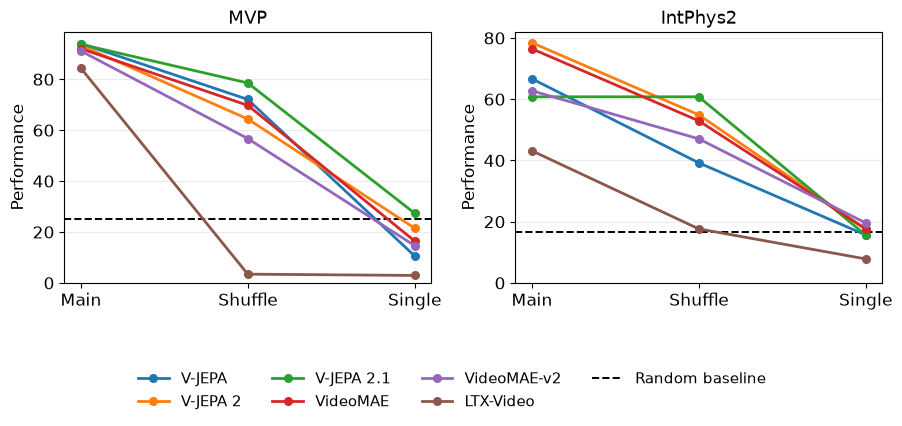

In [36]:
import os

mpl_config_dir = Path("/tmp") / "probe4physics-matplotlib"
mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
})

PLOT_PROBE = "Attentive"
RANDOM_BASELINES = {
    "MVP": 25.0,
    "IntPhys2": 100.0 / 6.0,
}
plot_metrics = ["Main", "Shuffle", "Single frame"]
plot_tick_labels = ["Main", "Shuffle", "Single"]
x = np.arange(len(plot_metrics))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0), sharey=False)

for ax, dataset_name in zip(axes, DATASETS):
    for model_name in absolute_table.index:
        y = [absolute_table.loc[model_name, (dataset_name, PLOT_PROBE, metric)] for metric in plot_metrics]
        ax.plot(x, y, marker="o", linewidth=2.0, markersize=5.5, label=model_name)
    ax.axhline(RANDOM_BASELINES[dataset_name], color="black", linestyle="--", linewidth=1.4, label="Random baseline", zorder=0)

    ax.set_title(dataset_name)
    ax.set_xticks(x, plot_tick_labels)
    ax.set_ylabel("Performance")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.16, 1, 1))
plt.show()
